# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Hana Talitha Syahda
- **Email:** hynanana03@gmail.com
- **ID Dicoding:** hanatalitha

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** State mana yang memiliki total revenue dan jumlah transaksi tertinggi selama periode Januari – Desember 2018, serta bagaimana kontribusinya terhadap total revenue sehingga dapat menjadi prioritas alokasi anggaran pemasaran dan dukungan logistik?
- **Pertanyaan 2:** Bagaimana hubungan antara rata-rata review score dan total revenue pada setiap kategori produk selama periode Januari – Desember 2018, serta kategori mana yang perlu diprioritaskan untuk peningkatan kualitas produk atau layanan berdasarkan nilai korelasinya?

## Import Semua Packages/Library yang Digunakan

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Memuat Dataset untuk Analisis Revenue per State dan Review per Kategori Produk

In [46]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [47]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [48]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [49]:
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [50]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [51]:
category_translation_df = pd.read_csv("product_category_name_translation.csv")
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- **'customers_dataset'** = Dataset customers berisi informasi lokasi pelanggan seperti city dan customer_state.
- **'orders_dataset'** = Dataset orders berisi informasi transaksi dan status pesanan.
- **'order_items_dataset'** = Dataset order_items berisi detail item pesanan, harga produk, dan ongkos kirim.
- **'order_reviews_dataset'** = Dataset reviews berisi skor ulasan pelanggan.

- **'products_dataset'** = Dataset products berisi informasi kategori produk.
- **'product_category_name_translation'** = Dataset category translation digunakan untuk menerjemahkan nama kategori produk agar lebih mudah dibaca.

### Assessing Data

#### Deteksi Missing Value, Duplikasi, dan Outlier pada Data

**Steps to Take:**
- **'df.info()'**, memeriksa informasi umum dataset seperti tipe data, jumlah baris dan kolom.
- **'df.isna().sum()'**, memeriksa apakah ada missing values di setiap kolom.
- **'df.duplicated().sum()'**, memeriksa apakah terdapat baris yang memiliki duplikasi.
- **'df.describe(include="all")'**, melihat distribusi, nilai min-max, mean, dan sebaran data.

In [52]:
display(customers_df.info())
display(customers_df.isna().sum())
print("Jumlah duplikasi customers:", customers_df.duplicated().sum())
display(customers_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


Jumlah duplikasi customers: 0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Insight**
- Dataset memiliki 99441 baris tanpa missing values dan tanpa duplikasi.
- Terdapat 96096 pelanggan unik, artinya sebagian kecil pelanggan (99441 - 96096 = 3.345) yang melakukan lebih dari satu transaksi.
- Kota dengan frekuensi terbanyak yaitu Sao Paulo dengan 15540 pelanggan, dan state yang paling banyak adalah SP dengan 41746 pelanggan.

In [53]:
display(orders_df.info())
display(orders_df.isna().sum())
print("Jumlah duplikasi orders:", orders_df.duplicated().sum())
display(orders_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Jumlah duplikasi orders: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight**
- Dataset memiliki 99441 baris tanpa duplikasi, tetapi terdapat missing values pada kolom **'order_approved_at'** (160), **'order_delivered_carrier_date'** (1783), dan **'order_delivered_customer_date'** (2965), hal tersebut karena tidak semua pesanan telah terkirim.
- Terdapat 8 status pesanan unik, dengan status terbanyak adalah **delivered** sebanyak 96478 pesanan.
- Semua kolom bertipe data **object**, sehingga kolom timestamp perlu diubah ke tipe datetime untuk analisis lebih lanjut.

In [54]:
display(order_items_df.info())
display(order_items_df.isna().sum())
print("Jumlah duplikasi order items: ", order_items_df.duplicated().sum())
display(order_items_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


Jumlah duplikasi order items:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight**
- Dataset memiliki 112650 baris tanpa missing values dan tanpa duplikasi.
- Mean harga produk adalah 120,65 dengan nilai maksimum mencapai 6735. Ini menunjukkan bahwa adanya produk bernilai sangat tinggi.
- Mean biaya pengiriman adalah 19,99 dengan nilai maksimum 409,68 serta sebagian besar pesanan hanya memiliki 1 item (median **'order_item_id'** = 1).

In [55]:
display(order_reviews_df.info())
display(order_reviews_df.isna().sum())
print("Jumlah duplikasi order reviews: ", order_reviews_df.duplicated().sum())
display(order_reviews_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


None

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


Jumlah duplikasi order reviews:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight**
- Dataset memiliki 99224 baris tanpa duplikasi, tetapi terdapat banyak missing values pada kolom **'review_comment_title'** (87656) dan **'review_comment_message'** (58247). Hal ini menunjukkan bahwa sebagian besar pelanggan tidak mengisi komentar review.
- Mean skor review adalah 4,09 dengan median 5. Hal ini menunjukkan bahwa sebagian besar pelanggan memberikan review positif (5).

In [56]:
display(products_df.info())
display(products_df.isna().sum())
print("Jumlah duplikasi products: ", products_df.duplicated().sum())
display(products_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


Jumlah duplikasi products:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight**
- Dataset memiliki 32951 baris tanpa duplikasi, tetapi terdapat missing values pada beberapa  kolom seperti **'product_name_lenght'**, **'product_description_lenght'**, dan **'product_photos_qty'** (masing-masing 610) serta **'product_weight_g'**, **'product_length_cm'**, **'product_height_cm'**, dan **'product_width_cm'** (masing-masing 2).
- Mean berat produk adalah 2276,27 gram dengan maksimum 40425 gram. Hal ini menunjukkan bahwa adanya produk dengan berat yang sangat besar.
- Mean jumlah foto produk adalah 2,19 dengan maksimum 20 foto, serta sebagian besar produk hanya memiliki 1 foto (median = 1).

In [57]:
display(category_translation_df.info())
display(category_translation_df.isna().sum())
print("Jumlah duplikasi product translation:", category_translation_df.duplicated().sum())
display(category_translation_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

,0
product_category_name,0
product_category_name_english,0


Jumlah duplikasi product translation: 0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight**
- Dataset memiliki 71 baris tanpa missing values dan tanpa duplikasi.
- Terdapat 71 kategori unik yang masing-masing memiliki terjemahan dari bahasa Portugis ke bahasa Inggris. Hal ini untuk mempermudah mengetahui terjemahan kategori produk secara global.

### Cleaning Data

#### Pembersihan Missing Value, Duplikasi, dan Nilai Tidak Valid

In [58]:
all_df = orders_df.merge(order_items_df, on='order_id') \
           .merge(customers_df, on='customer_id') \
           .merge(order_reviews_df, on='order_id') \
           .merge(products_df, on='product_id') \
           .merge(category_translation_df, on='product_category_name', how='left')

**Insight**
- Menggabungkan semua dataset menjadi satu dataframe untuk memudahkan proses analisis.

In [59]:
all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])

**Insight**
- Mengubah tipe data timestamp ke datetime agar dapat digunakan untuk analisis berbasis waktu.

In [60]:
all_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1184
order_delivered_customer_date,2360
order_estimated_delivery_date,0
order_item_id,0
product_id,0


 **Insight**
 - Terdapat missing values pada beberapa kolom. Kolom yang tidak digunakan dalam analisis utama dapat diabaikan, sedangkan kolom **'product_category_name_english'** perlu ditangani.

In [61]:
all_df = all_df.drop_duplicates()

**Insight**
- Menghapus duplikasi data untuk memastikan setiap baris merepresentasikan 1 transaksi unik.

In [62]:
all_df['product_category_name_english'] = all_df['product_category_name_english'].fillna('Unknown')

**Insight**
- Mengisi missing values pada kolom kategori dengan ('Unknown') agar tidak ada data yang hilang.

In [63]:
all_df = all_df[['order_id', 'order_purchase_timestamp', 'customer_id', 'customer_state',
         'product_id', 'product_category_name_english', 'price', 'review_score']]

**Insight**
- Memfilter kolom yang relevan dengan pertanyaan bisnis agar dataset lebih ringkas.

In [64]:
all_df_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

**Insight**
- Memfilter data untuk mengambil transaksi pada periode Januari - Desember 2018 sesuai dengan fokus pertanyaan bisnis.

In [65]:
all_df_2018.to_csv('main_data.csv', index=False)

**Insight**
- Menyimpan hasil cleaning ke CSV baru sebagai data utama

## Exploratory Data Analysis (EDA)

### Eksplorasi Distribusi Revenue, Transaksi per State, dan Hubungan Review Score vs Revenue per Kategori Produk

In [66]:
state_analysis = all_df_2018.groupby('customer_state').agg(
    total_revenue=('price', 'sum'),
    total_transaksi=('order_id', 'count')
).reset_index()

state_analysis = state_analysis.sort_values('total_revenue', ascending=False)
state_analysis.head(10)

,customer_state,total_revenue,total_transaksi
25,SP,2973750.22,27233
18,RJ,898020.74,7435
10,MG,853543.49,6936
22,RS,387789.91,3216
17,PR,385688.62,3141
23,SC,278288.40,2217
4,BA,271423.58,1969
6,DF,166589.19,1347
8,GO,154896.18,1214
7,ES,144331.49,1162


**Insight**

**Menjawab Pertanyaan Bisnis 1**

- Mengelompokkan data berdasarkan state untuk menghitung total revenue dan jumlah transaksi, kemudian disajikan pada 10 state teratas agar state dengan kontribusi terbesar dapat diidentifikasi sebagai prioritas alokasi anggaran pemasaran dan dukungan logistik.

In [67]:
category_analysis = all_df_2018.groupby('product_category_name_english').agg(
    avg_review_score=('review_score', 'mean'),
    total_revenue=('price', 'sum')
).reset_index()

category_analysis = category_analysis.sort_values('total_revenue', ascending=False)
category_analysis.head(10)

,product_category_name_english,avg_review_score,total_revenue
44,health_beauty,4.152949,767971.79
70,watches_gifts,3.981512,703737.87
8,bed_bath_table,3.884734,536633.16
65,sports_leisure,4.048094,530437.77
16,computers_accessories,3.880575,507155.05
50,housewares,4.045669,398066.96
40,furniture_decor,3.906478,385985.12
6,auto,4.100725,345791.18
7,baby,3.986441,255258.82
21,cool_stuff,4.053315,238015.36


**Insight:**

**Menjawab Pertanyaan Bisnis 2**
- Mengelompokkan data berdasarkan kategori produk untuk menghitung rata-rata skor review dan total revenue, sehingga dapat dilihat pola hubungan antara skor review dan pendapatan per kategori.

In [68]:
correlation = category_analysis['avg_review_score'].corr(category_analysis['total_revenue'])
print(f'Nilai Korelasi: {correlation:.3f}')

Nilai Korelasi: -0.026


**Insight**

**Analisis Hubungan Review Score dan Revenue**
- Nilai korelasi sebesar -0.026 menunjukkan hubungan yang sangat lemah antara review score dan revenue.
- Hal ini berarti kepuasan pelanggan tidak secara langsung mempengaruhi besar kecilnya revenue. Oleh karena itu, prioritas peningkatan kualitas produk atau layanan sebaiknya difokuskan pada kategori dengan review score rendah namun memiliki total revenue tinggi, karena kategori tersebut memiliki potensi pasar besar namun belum optimal dalam kepuasan pelanggan.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Visualisasi Revenue dan Transaksi per State

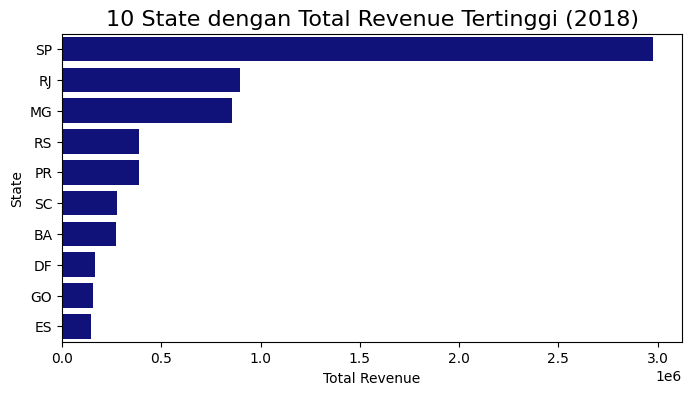

In [69]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=state_analysis.head(10),
    x='total_revenue',
    y='customer_state',
    color='darkblue'
)
plt.title('10 State dengan Total Revenue Tertinggi (2018)', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('State')
plt.show()

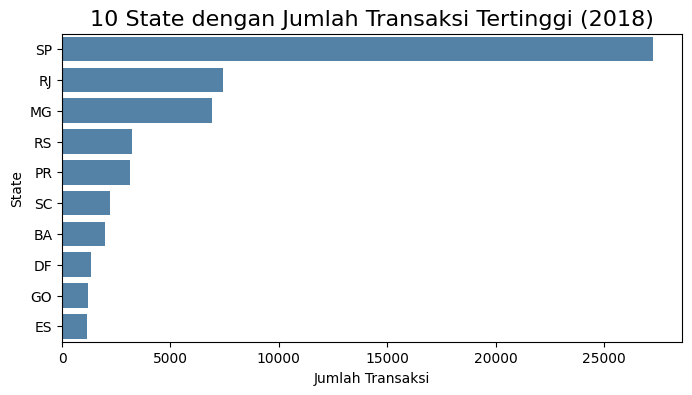

In [70]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=state_analysis.head(10),
    x='total_transaksi',
    y='customer_state',
    color='steelblue'
)
plt.title('10 State dengan Jumlah Transaksi Tertinggi (2018)', fontsize=16)
plt.xlabel('Jumlah Transaksi')
plt.ylabel('State')
plt.show()

**Insight**
- State SP merupakan state dengan revenue tertinggi sekaligus jumlah transaksi terbesar.
- Hal ini menunjukkan bahwa aktivitas e-commerce paling tinggi terkonsentrasi di wilayah tersebut.
- State lain seperti RJ dan MG juga memberikan kontribusi yang cukup besar, namun masih di bawah SP.
- Visualisasi menunjukkan adanya ketimpangan distribusi revenue antar state. Oleh karena itu, state SP, RJ, dan MG dapat dijadikan prioritas utama dalam alokasi anggaran pemasaran dan dukungan logistik.

### Pertanyaan 2: Visualisasi Hubungan Review Score dan Revenue per Kategori Produk

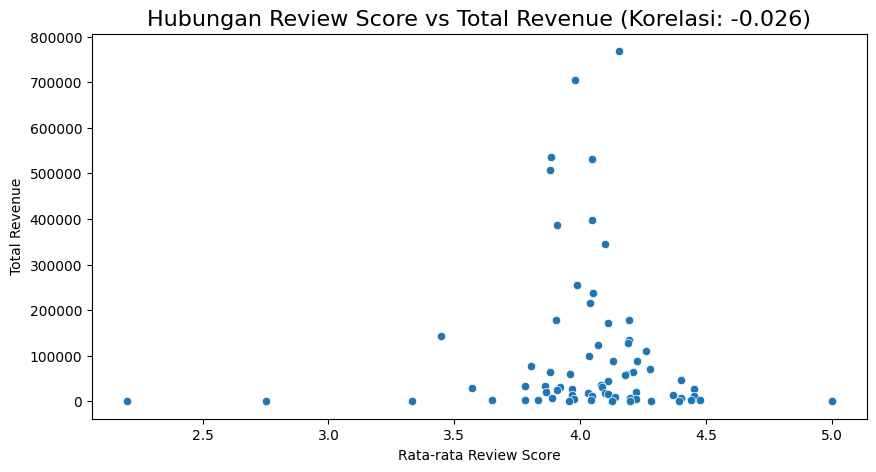

In [71]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=category_analysis,
    x='avg_review_score',
    y='total_revenue'
)
plt.title(f'Hubungan Review Score vs Total Revenue (Korelasi: {correlation:.3f})', fontsize=16)
plt.xlabel('Rata-rata Review Score')
plt.ylabel('Total Revenue')
plt.show()

**Insight**
- Kategori produk **'health_beauty'** memiliki revenue tertinggi dibandingkan kategori lainnya.
- Kategori seperti **'watches_gifts'** dan **'bed_bath_table'** juga memberikan kontribusi revenue yang besar.
- Sebagian besar kategori memiliki review score tinggi (di atas 4), yang menunjukkan tingkat kepuasan pelanggan cukup baik.
- Namun, tidak terdapat hubungan yang kuat antara review score dan revenue dikonfirmasi oleh nilai korelasi sebesar -0.026.
- Hal ini menunjukkan bahwa faktor lain seperti jumlah transaksi dan harga produk lebih memengaruhi revenue dibandingkan review score. Oleh karena itu, kategori dengan review score rendah namun revenue tinggi perlu diprioritaskan untuk peningkatan kualitas produk atau layanan sebagai dasar strategi pengelolaan portofolio produk.

## Conclusion & Recommendation

- Conclusion pertanyaan 1: Berdasarkan hasil analisis, state SP memiliki total revenue dan jumlah transaksi paling tinggi dibandingkan state lainnya, diikuti oleh RJ dan MG. Hal ini menunjukkan bahwa aktivitas e-commerce dalam dataset ini lebih banyak terjadi di wilayah tersebut, sehingga ketiga state tersebut dapat menjadi prioritas utama dalam alokasi anggaran pemasaran dan dukungan logistik.
- Conclusion pertanyaan 2: Kategori **'health_beauty'** menjadi penyumbang revenue terbesar. Meskipun sebagian besar kategori memiliki review score yang tinggi, hasil analisis menunjukkan bahwa tidak terdapat hubungan yang kuat antara review score dan revenue, dengan nilai korelasi sebesar **-0.026**. Dengan demikian, performa penjualan tidak hanya dipengaruhi oleh tingkat kepuasan pelanggan, sehingga kategori dengan review score rendah namun revenue tinggi perlu diprioritaskan untuk peningkatan kualitas produk atau layanan.

**Rekomendasi Action Item:**
1. Mengalokasikan anggaran pemasaran dan dukungan logistik lebih besar pada state SP, RJ, dan MG sebagai wilayah dengan total revenue dan jumlah transaksi tertinggi, serta melakukan strategi ekspansi pasar ke state dengan revenue rendah untuk mengurangi ketimpangan distribusi revenue antar wilayah.
2. Mempertahankan ketersediaan dan kualitas produk pada kategori **'health_beauty'**, **'watches_gifts'**, dan **'bed_bath_table'** yang sudah berkontribusi besar terhadap revenue agar potensi penjualan tetap optimal.
3. Karena nilai korelasi antara review score dan revenue hanya sebesar **-0.026**, perlu dipertimbangkan faktor lain seperti harga produk dan jumlah transaksi sebagai fokus utama strategi peningkatan revenue.
4. Memprioritaskan peningkatan kualitas produk dan layanan pada kategori dengan review score rendah namun memiliki revenue tinggi sebagai dasar strategi pengelolaan portofolio produk.
